# Phase 6 — Error Analysis

In [1]:
import sys
sys.path.append('../src')

import csv
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

from config import METADATA_DIR, MISCLASSIFIED_DIR, ensure_dirs

ensure_dirs()


## 1. Load predictions, isolate misclassified samples

In [2]:
preds_csv = METADATA_DIR / 'test_predictions.csv'
with open(preds_csv) as f:
    rows = list(csv.DictReader(f))

total = len(rows)
misclassified = [r for r in rows if r['correct'] == '0']

print(f"Total test samples : {total}")
print(f"Misclassified       : {len(misclassified)} ({len(misclassified)/total:.2%})")


Total test samples : 8179
Misclassified       : 194 (2.37%)


## 2. Group by confused class-pair

In [3]:
pair_counts = Counter(
    (r['true_class'], r['pred_class']) for r in misclassified
)

print("Confused pairs, ranked by count (true -> predicted):\n")
for (true_c, pred_c), count in pair_counts.most_common(15):
    print(f"  {true_c:45s} -> {pred_c:45s} : {count}")


Confused pairs, ranked by count (true -> predicted):

  Tomato___Tomato_Yellow_Leaf_Curl_Virus        -> Tomato___Bacterial_spot                       : 25
  Tomato___Late_blight                          -> Tomato___Early_blight                         : 19
  Soybean___healthy                             -> Pepper,_bell___healthy                        : 15
  Corn_(maize)___Northern_Leaf_Blight           -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : 12
  Soybean___healthy                             -> Apple___healthy                               : 8
  Soybean___healthy                             -> Raspberry___healthy                           : 7
  Tomato___Target_Spot                          -> Tomato___Spider_mites Two-spotted_spider_mite : 7
  Grape___Black_rot                             -> Grape___Esca_(Black_Measles)                  : 6
  Pepper,_bell___healthy                        -> Raspberry___healthy                           : 6
  Tomato___Tomato_Yellow_Lea

## 3. Is confusion within-crop or cross-crop?

In [4]:
def crop_name(class_name):
    # PlantVillage class names are 'Crop___Disease' — take the crop part
    return class_name.split('___')[0]

within_crop = 0
cross_crop = 0

for r in misclassified:
    if crop_name(r['true_class']) == crop_name(r['pred_class']):
        within_crop += 1
    else:
        cross_crop += 1

print(f"Within-crop confusion : {within_crop} ({within_crop/len(misclassified):.1%})")
print(f"Cross-crop confusion  : {cross_crop} ({cross_crop/len(misclassified):.1%})")

if cross_crop > 0:
    print("\nCross-crop confusion examples (worth a closer look):")
    cross_examples = [r for r in misclassified if crop_name(r['true_class']) != crop_name(r['pred_class'])]
    for r in cross_examples[:10]:
        print(f"  {r['true_class']} -> {r['pred_class']}  (conf: {r['confidence']})")


Within-crop confusion : 118 (60.8%)
Cross-crop confusion  : 76 (39.2%)

Cross-crop confusion examples (worth a closer look):
  Apple___healthy -> Blueberry___healthy  (conf: 0.5251)
  Apple___healthy -> Blueberry___healthy  (conf: 0.8803)
  Apple___healthy -> Blueberry___healthy  (conf: 0.6969)
  Apple___healthy -> Blueberry___healthy  (conf: 0.5109)
  Apple___healthy -> Blueberry___healthy  (conf: 0.8016)
  Blueberry___healthy -> Strawberry___healthy  (conf: 0.9793)
  Cherry_(including_sour)___Powdery_mildew -> Blueberry___healthy  (conf: 0.3919)
  Cherry_(including_sour)___Powdery_mildew -> Blueberry___healthy  (conf: 0.7026)
  Cherry_(including_sour)___healthy -> Apple___healthy  (conf: 0.7184)
  Orange___Haunglongbing_(Citrus_greening) -> Blueberry___healthy  (conf: 0.3540)


## 4. Are errors concentrated in specific (especially small) classes?

In [5]:
true_class_errors = Counter(r['true_class'] for r in misclassified)
true_class_totals = Counter(r['true_class'] for r in rows)

print(f"{'Class':45s} {'Errors':>8s} {'Total':>8s} {'Error rate':>12s}")
for class_name, total_count in sorted(true_class_totals.items(), key=lambda x: x[1]):
    error_count = true_class_errors.get(class_name, 0)
    error_rate = error_count / total_count if total_count else 0
    marker = '  <-- small class' if total_count < 100 else ''
    print(f"{class_name:45s} {error_count:8d} {total_count:8d} {error_rate:11.1%}{marker}")


Class                                           Errors    Total   Error rate
Potato___healthy                                     0       24        0.0%  <-- small class
Apple___Cedar_apple_rust                             0       42        0.0%  <-- small class
Peach___healthy                                      0       55        0.0%  <-- small class
Raspberry___healthy                                  0       57        0.0%  <-- small class
Tomato___Tomato_mosaic_virus                         0       57        0.0%  <-- small class
Grape___healthy                                      0       64        0.0%  <-- small class
Strawberry___healthy                                 0       69        0.0%  <-- small class
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot        5       78        6.4%  <-- small class
Apple___Black_rot                                    0       94        0.0%  <-- small class
Apple___Apple_scab                                   1       95        1.1%  <-- 

## 5. Save misclassified sample images, grouped by confused pair

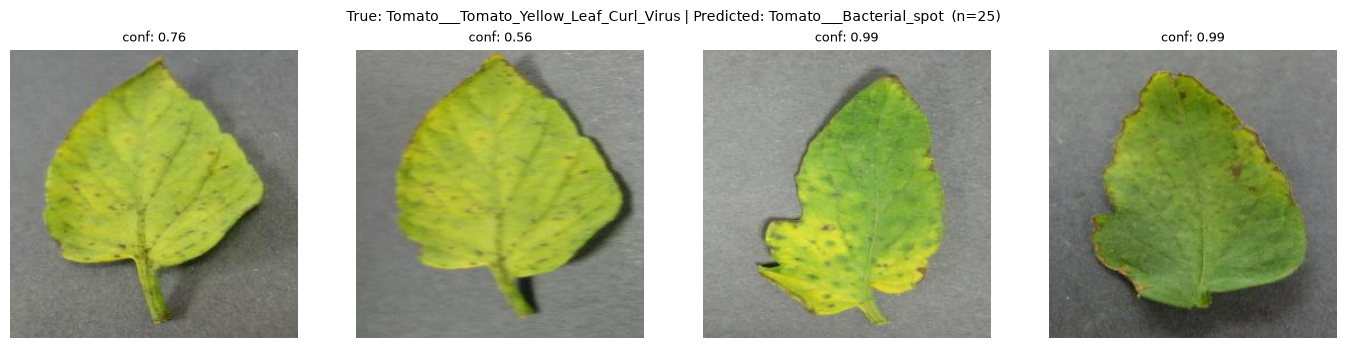

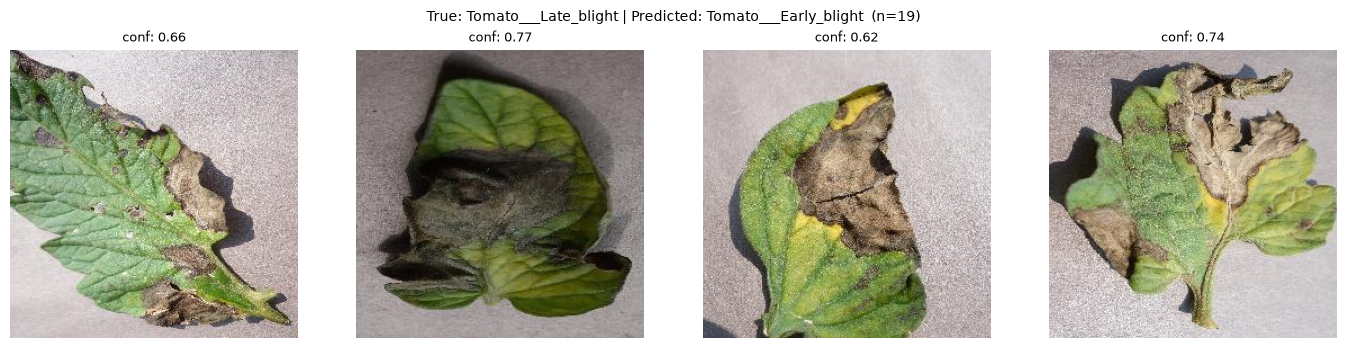

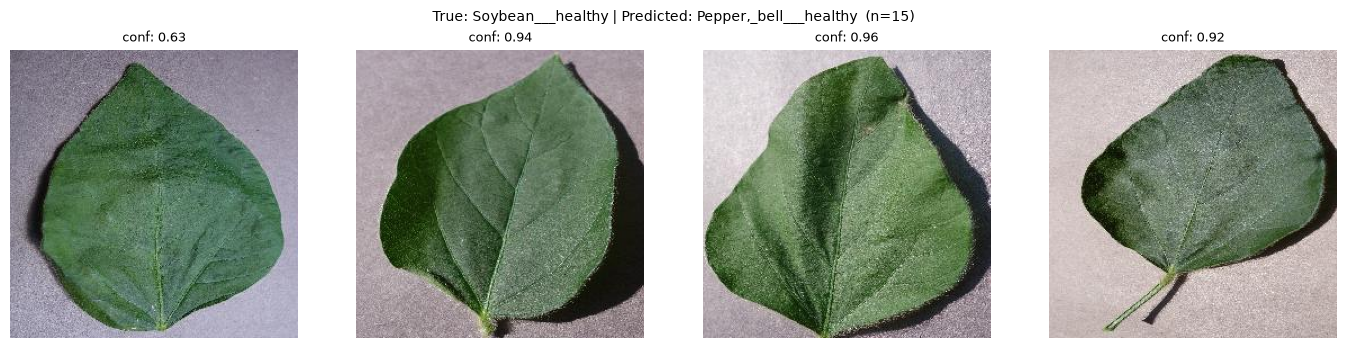

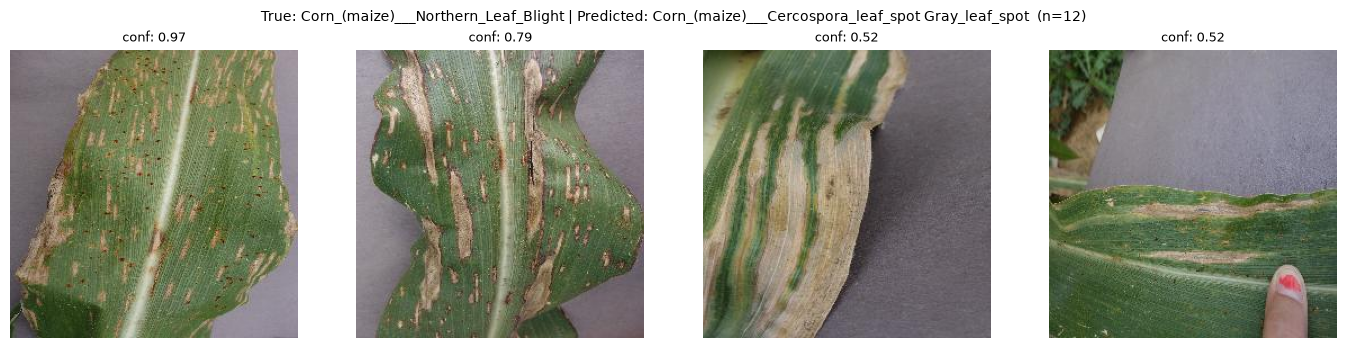

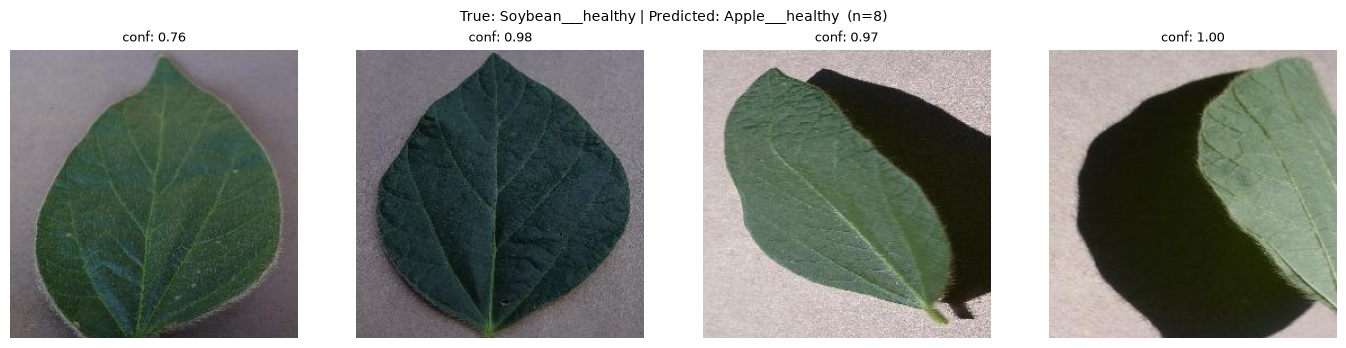

In [6]:
top_n_pairs = 5
top_pairs = pair_counts.most_common(top_n_pairs)

for (true_c, pred_c), count in top_pairs:
    pair_rows = [r for r in misclassified if r['true_class'] == true_c and r['pred_class'] == pred_c]
    n_show = min(4, len(pair_rows))

    fig, axes = plt.subplots(1, n_show, figsize=(3.5 * n_show, 3.5))
    if n_show == 1:
        axes = [axes]

    for ax, r in zip(axes, pair_rows[:n_show]):
        img = Image.open(r['filepath'])
        ax.imshow(img)
        ax.set_title(f"conf: {float(r['confidence']):.2f}", fontsize=9)
        ax.axis('off')

    fig.suptitle(f"True: {true_c} | Predicted: {pred_c}  (n={count})", fontsize=10)
    plt.tight_layout()

    safe_name = f"{true_c}__as__{pred_c}".replace('/', '_').replace(',', '')
    save_path = MISCLASSIFIED_DIR / f"{safe_name}.png"
    plt.savefig(save_path, dpi=120)
    plt.show()


## 6. Confidence check on misclassified samples

In [7]:
confidences = [float(r['confidence']) for r in misclassified]

low_conf = [r for r in misclassified if float(r['confidence']) < 0.5]
high_conf_wrong = [r for r in misclassified if float(r['confidence']) >= 0.9]

print(f"Misclassified with confidence < 0.5  (model was unsure): {len(low_conf)} ({len(low_conf)/len(misclassified):.1%})")
print(f"Misclassified with confidence >= 0.9 (model was CONFIDENT and wrong): {len(high_conf_wrong)} ({len(high_conf_wrong)/len(misclassified):.1%})")

if high_conf_wrong:
    print("\nHigh-confidence wrong predictions (worth inspecting individually):")
    for r in sorted(high_conf_wrong, key=lambda x: -float(x['confidence']))[:10]:
        print(f"  {r['true_class']} -> {r['pred_class']}  (conf: {r['confidence']})  {Path(r['filepath']).name}")


Misclassified with confidence < 0.5  (model was unsure): 15 (7.7%)
Misclassified with confidence >= 0.9 (model was CONFIDENT and wrong): 51 (26.3%)

High-confidence wrong predictions (worth inspecting individually):
  Tomato___Target_Spot -> Tomato___Tomato_mosaic_virus  (conf: 0.9996)  21aa9ddb-0051-41c7-b1e3-316c20c64483___Com.G_TgS_FL 8151.JPG
  Soybean___healthy -> Apple___healthy  (conf: 0.9991)  5e85916d-d71c-447a-b21b-c1c9434c0c37___RS_HL 3619.JPG
  Strawberry___Leaf_scorch -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot  (conf: 0.9958)  30e43c7d-0621-4827-8a3a-3ae771996f1e___RS_L.Scorch 9959.JPG
  Corn_(maize)___Northern_Leaf_Blight -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot  (conf: 0.9954)  11b9b0d7-738b-407b-8ca4-4c6500e6aebd___RS_NLB 3892.JPG
  Tomato___Tomato_Yellow_Leaf_Curl_Virus -> Tomato___Bacterial_spot  (conf: 0.9952)  92f5b61b-1970-41b3-9c72-f648feadd735___UF.GRC_YLCV_Lab 08482.JPG
  Tomato___Tomato_Yellow_Leaf_Curl_Virus -> Tomato___Bacterial_spot  